<h1 style="color:#56B4E9;">Week 7 — Day 1</h1>

<h2 style="color:#0072B2;">Sprint 2 Planning and Convolutional Neural Networks</h2>

### Melanoma Skin Cancer Classification

During Week 6, a fully connected neural network was used to learn from manually extracted ECG features.

Week 7 begins the second project sprint and introduces architectures that preserve the structure of their input data. This notebook focuses on Convolutional Neural Networks using dermoscopic skin-lesion images.

The selected dataset contains two classes:

- `Benign`: non-cancerous skin lesions.
- `Malignant`: cancerous melanoma lesions.

The goal of Day 1 is not to train the complete classifier. The goal is to understand how convolution, filters, and feature maps extract local visual patterns from medical images.

<h2 style="color:#0072B2;">Learning Objectives</h2>

By the end of this notebook, we will be able to:

- Define the Sprint 2 goal and core-model backlog.
- Explain why a dense network is inefficient for image data.
- Explain filters, convolution, and feature maps.
- Apply hand-defined edge-detection filters to a dermoscopic image.
- Explain stride, padding, and parameter sharing.
- Justify using a two-dimensional CNN for the melanoma classification project.

<h2 style="color:#0072B2;">Sprint 2 Plan</h2>

<span style="color:#D55E00;"><b>Problem:</b></span>  
A dense network requires flattening an image into one long vector. This removes the explicit spatial relationships between neighboring pixels and creates a very large number of trainable parameters.

<span style="color:#009E73;"><b>Sprint 2 Goal:</b></span>  
Develop a convolutional image-classification model that distinguishes benign from malignant skin lesions and improves upon a simple baseline.

### Core-Model Backlog

1. Inspect the melanoma dataset and verify its class structure.
2. Demonstrate convolution using manually defined edge filters.
3. Build a CNN from scratch.
4. Introduce data augmentation and compare validation behavior.
5. Apply transfer learning using a pre-trained image model.
6. Compare all experiments using clinically meaningful metrics.
7. Select and evaluate the best model on the test set.

### Primary Evaluation Decision

Because predicting a malignant lesion as benign is the more dangerous error, the main evaluation focus will be:

- Malignant-class Recall
- F2-score
- Confusion Matrix

Accuracy and F1-score will also be reported, but they will not be interpreted alone.

In [2]:
from pathlib import Path
import random

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from PIL import Image


SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Environment prepared successfully.")

Environment prepared successfully.


In [3]:
dataset_path = Path(
    kagglehub.dataset_download(
        "ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant"
    )
)

print("Dataset path:")
print(dataset_path)

100%|██████████| 79.4M/79.4M [00:03<00:00, 24.7MB/s]

Extracting files...


Dataset path:
/home/haitham/.cache/kagglehub/datasets/ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant/versions/1


In [4]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

records = []

for image_path in dataset_path.rglob("*"):
    if not image_path.is_file():
        continue

    if image_path.suffix.lower() not in image_extensions:
        continue

    path_parts = [part.lower() for part in image_path.parts]

    label = next(
        (
            class_name
            for class_name in ["benign", "malignant"]
            if class_name in path_parts
        ),
        None
    )

    split = next(
        (
            split_name
            for split_name in ["train", "validation", "valid", "val", "test"]
            if split_name in path_parts
        ),
        "unspecified"
    )

    if label is not None:
        records.append({
            "path": image_path,
            "split": split,
            "label": label
        })

image_data = pd.DataFrame(records)

print("Detected images:", len(image_data))
display(image_data.head())

Detected images: 13879


,path,split,label
0,/home/haitham/.cache/kagglehub/datasets/ailear...,test,benign
1,/home/haitham/.cache/kagglehub/datasets/ailear...,test,benign
2,/home/haitham/.cache/kagglehub/datasets/ailear...,test,benign
3,/home/haitham/.cache/kagglehub/datasets/ailear...,test,benign
4,/home/haitham/.cache/kagglehub/datasets/ailear...,test,benign


In [5]:
class_distribution = pd.crosstab(
    image_data["split"],
    image_data["label"],
    margins=True
)

display(class_distribution)

print("\nMissing paths:")
print((~image_data["path"].apply(Path.exists)).sum())

print("\nDuplicate paths:")
print(image_data["path"].duplicated().sum())

label,benign,malignant,All
split,,,
test,1000,1000,2000
train,6289,5590,11879
All,7289,6590,13879



Missing paths:
0

Duplicate paths:
0


In [6]:
sample_images = (
    image_data
    .groupby(["split", "label"], group_keys=False)
    .sample(n=1, random_state=SEED)
    .reset_index(drop=True)
)

display(sample_images[["split", "label", "path"]])

,split,label,path
0,test,benign,/home/haitham/.cache/kagglehub/datasets/ailear...
1,test,malignant,/home/haitham/.cache/kagglehub/datasets/ailear...
2,train,benign,/home/haitham/.cache/kagglehub/datasets/ailear...
3,train,malignant,/home/haitham/.cache/kagglehub/datasets/ailear...


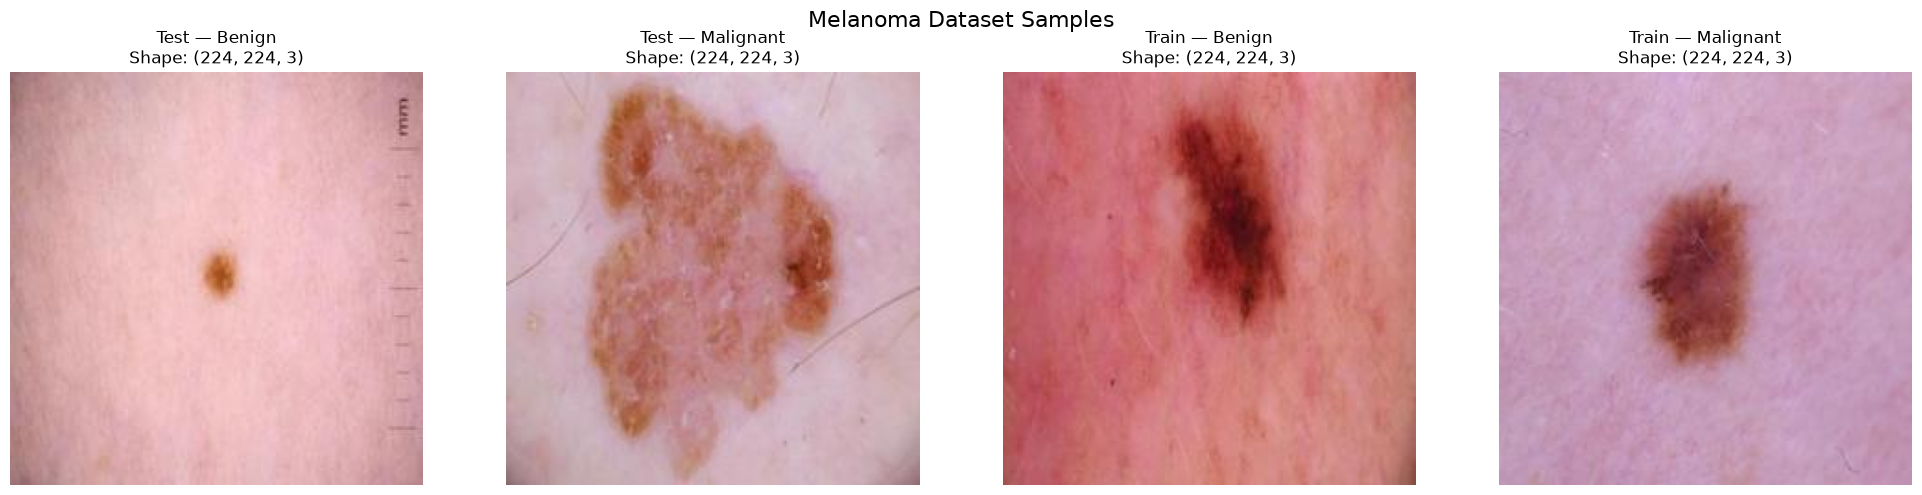

In [7]:
number_of_images = len(sample_images)

fig, axes = plt.subplots(
    1,
    number_of_images,
    figsize=(5 * number_of_images, 5)
)

if number_of_images == 1:
    axes = [axes]

for axis, row in zip(axes, sample_images.itertuples()):
    image = Image.open(row.path).convert("RGB")

    axis.imshow(image)
    axis.set_title(
        f"{row.split.title()} — {row.label.title()}\n"
        f"Shape: {np.asarray(image).shape}"
    )
    axis.axis("off")

plt.suptitle("Melanoma Dataset Samples", fontsize=16)
plt.tight_layout()
plt.show()

<h3 style="color:#009E73;">Dataset Inspection Results</h3>

The dataset contains `13,879` dermoscopic images:

| Split | Benign | Malignant | Total |
|---|---:|---:|---:|
| Training | 6,289 | 5,590 | 11,879 |
| Test | 1,000 | 1,000 | 2,000 |
| Total | 7,289 | 6,590 | 13,879 |

The training set is reasonably balanced, although benign images are slightly more common than malignant images. The test set is perfectly balanced.

No missing image paths or duplicate paths were detected.

<span style="color:#D55E00;"><b>Important Observation:</b></span>  
The dataset provides training and test sets, but it does not provide a separate validation set. A stratified validation subset must therefore be created later from the training data. The test set must remain untouched until the final evaluation.

<span style="color:#009E73;"><b>Medical Evaluation Decision:</b></span>  
Class balance makes accuracy more informative than it would be in a severely imbalanced dataset. However, malignant-class Recall remains the primary metric because a false-negative malignant prediction is clinically more dangerous than a false-positive warning.

Selected class: Malignant
Image path: /home/haitham/.cache/kagglehub/datasets/ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant/versions/1/train/Malignant/3995.jpg
RGB shape: (224, 224, 3)
Grayscale shape: (224, 224)
Grayscale range: 0.094 to 0.816


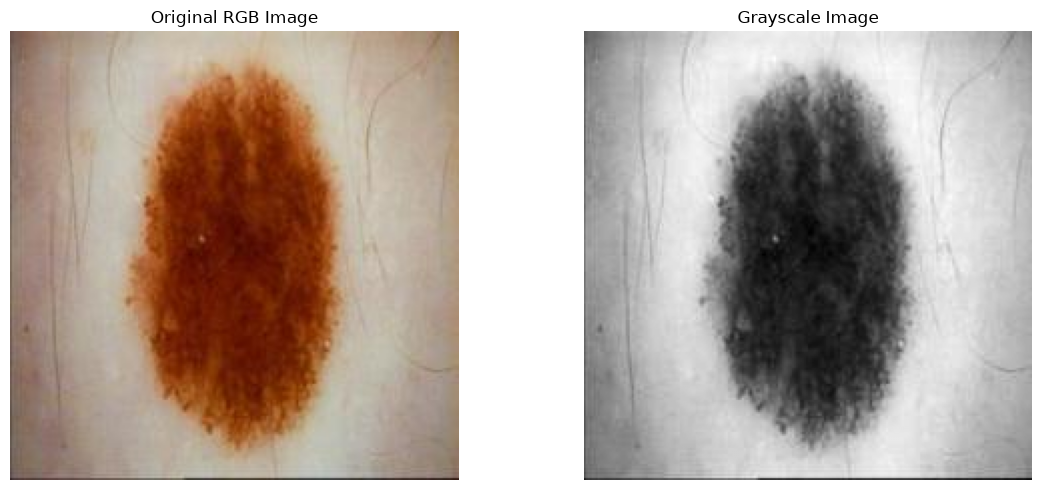

In [8]:
malignant_sample_path = (
    image_data[
        (image_data["split"] == "train")
        & (image_data["label"] == "malignant")
    ]
    .sample(n=1, random_state=SEED)
    ["path"]
    .iloc[0]
)

original_image = Image.open(malignant_sample_path).convert("RGB")
grayscale_image = original_image.convert("L")

rgb_array = np.asarray(original_image)
grayscale_array = np.asarray(grayscale_image, dtype=np.float32) / 255.0

print("Selected class: Malignant")
print("Image path:", malignant_sample_path)
print("RGB shape:", rgb_array.shape)
print("Grayscale shape:", grayscale_array.shape)
print(
    "Grayscale range:",
    round(float(grayscale_array.min()), 3),
    "to",
    round(float(grayscale_array.max()), 3)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(original_image)
axes[0].set_title("Original RGB Image")
axes[0].axis("off")

axes[1].imshow(grayscale_array, cmap="gray")
axes[1].set_title("Grayscale Image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

<h2 style="color:#0072B2;">Manual Two-Dimensional Convolution</h2>

A filter is a small grid of weights that moves across the image. At every location, the filter and the corresponding image region are multiplied element by element and then summed.

For an image region \(X\) and a kernel \(K\), the output at location \((i,j)\) is:

$$
Y(i,j)
=
\sum_{m=0}^{k_h-1}
\sum_{n=0}^{k_w-1}
X(i+m,j+n)K(m,n)
$$

Repeating this operation across the complete image produces a feature map.

The following implementation uses the same direct kernel operation commonly called convolution in CNN frameworks. More precisely, it is cross-correlation because the kernel is not mathematically flipped.

In [9]:
def convolve_2d(image, kernel, stride=1, padding=0):
    image = np.asarray(image, dtype=np.float32)
    kernel = np.asarray(kernel, dtype=np.float32)

    if image.ndim != 2:
        raise ValueError("The input image must be two-dimensional.")

    if kernel.ndim != 2:
        raise ValueError("The kernel must be two-dimensional.")

    if stride < 1:
        raise ValueError("Stride must be at least 1.")

    padded_image = np.pad(
        image,
        pad_width=padding,
        mode="constant",
        constant_values=0
    )

    image_height, image_width = padded_image.shape
    kernel_height, kernel_width = kernel.shape

    output_height = (
        (image_height - kernel_height) // stride
    ) + 1

    output_width = (
        (image_width - kernel_width) // stride
    ) + 1

    feature_map = np.zeros(
        (output_height, output_width),
        dtype=np.float32
    )

    for output_row in range(output_height):
        for output_column in range(output_width):
            row_start = output_row * stride
            column_start = output_column * stride

            image_region = padded_image[
                row_start:row_start + kernel_height,
                column_start:column_start + kernel_width
            ]

            feature_map[output_row, output_column] = np.sum(
                image_region * kernel
            )

    return feature_map

In [10]:
vertical_edge_kernel = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

horizontal_edge_kernel = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]
], dtype=np.float32)

vertical_feature_map = convolve_2d(
    grayscale_array,
    vertical_edge_kernel,
    stride=1,
    padding=1
)

horizontal_feature_map = convolve_2d(
    grayscale_array,
    horizontal_edge_kernel,
    stride=1,
    padding=1
)

print("Input shape:", grayscale_array.shape)
print("Vertical feature-map shape:", vertical_feature_map.shape)
print("Horizontal feature-map shape:", horizontal_feature_map.shape)

Input shape: (224, 224)
Vertical feature-map shape: (224, 224)
Horizontal feature-map shape: (224, 224)


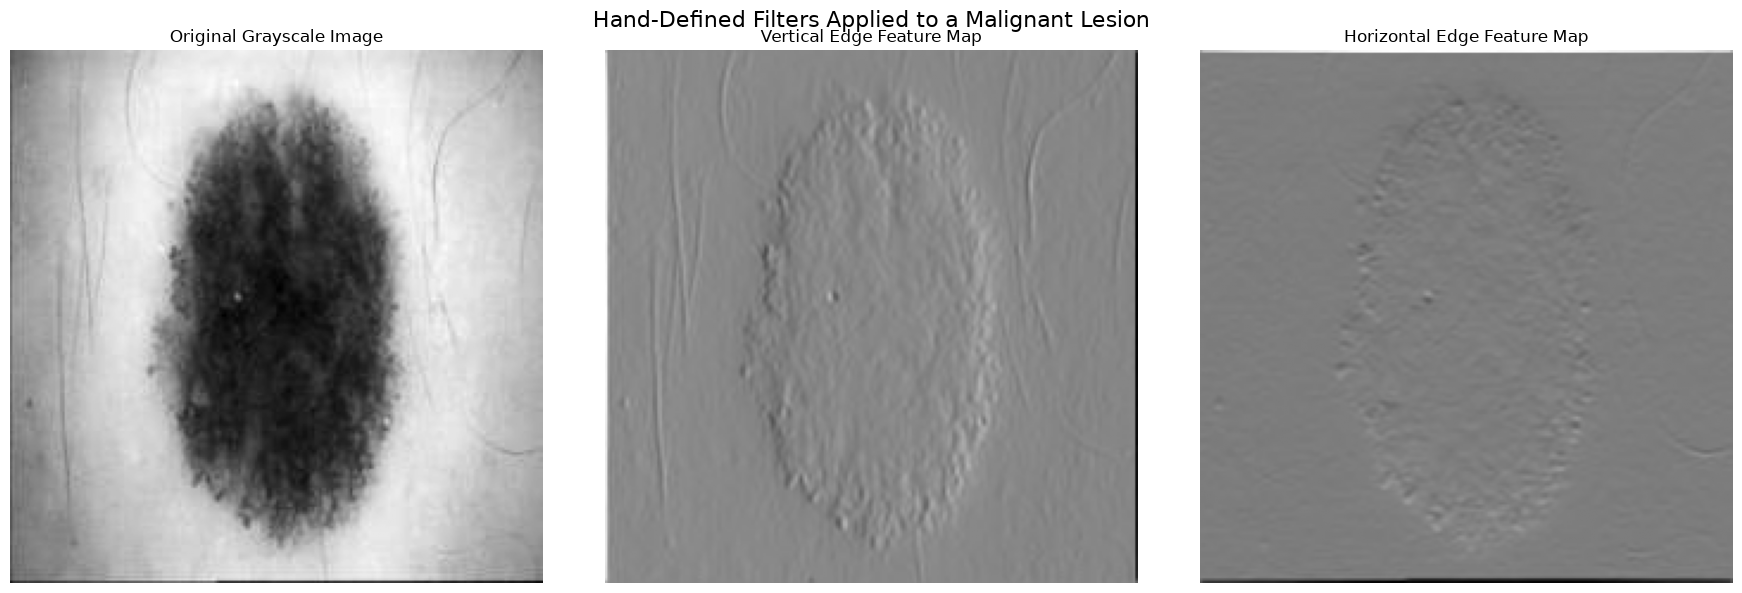

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(grayscale_array, cmap="gray")
axes[0].set_title("Original Grayscale Image")

axes[1].imshow(
    vertical_feature_map,
    cmap="gray"
)
axes[1].set_title("Vertical Edge Feature Map")

axes[2].imshow(
    horizontal_feature_map,
    cmap="gray"
)
axes[2].set_title("Horizontal Edge Feature Map")

for axis in axes:
    axis.axis("off")

plt.suptitle(
    "Hand-Defined Filters Applied to a Malignant Lesion",
    fontsize=16
)
plt.tight_layout()
plt.show()

<h3 style="color:#009E73;">Edge-Detection Results</h3>

The original malignant image had a grayscale shape of:

$$
(224,224)
$$

Both feature maps also had the shape:

$$
(224,224)
$$

because a padding of one pixel compensated for the size reduction caused by the \(3\times3\) kernels.

The vertical-edge filter responded strongly to left-to-right intensity changes, while the horizontal-edge filter responded to top-to-bottom changes. Consequently, the feature maps emphasized parts of the lesion boundary, internal texture changes, and other strong transitions in the image.

<span style="color:#D55E00;"><b>Important Limitation:</b></span>  
The hand-defined filters do not diagnose melanoma. They only demonstrate how local visual patterns can be extracted. They may also respond to hair, lighting changes, image borders, and unrelated skin texture.

A trained CNN does not rely on only these two filters. It learns many filters from the training labels and combines their feature maps across several layers.

The grayscale conversion was used only to make the manual calculation easy to understand. The final classification model should preserve the three RGB channels because lesion color may contain useful diagnostic information.

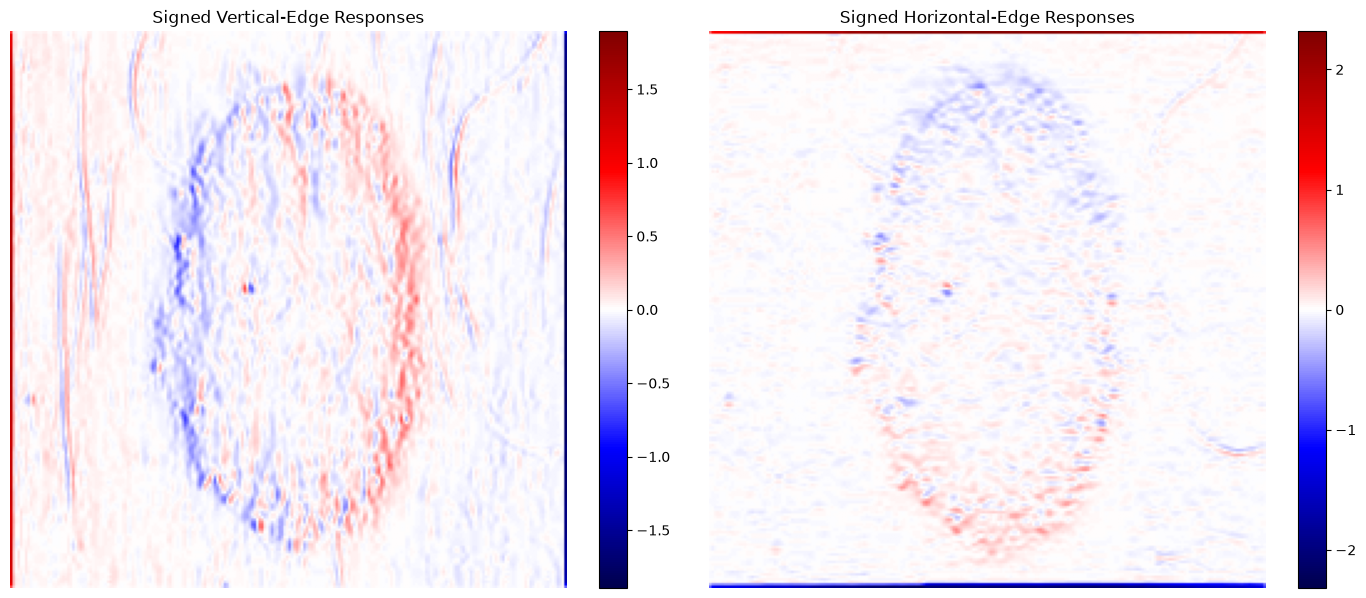

In [12]:
vertical_limit = np.max(np.abs(vertical_feature_map))
horizontal_limit = np.max(np.abs(horizontal_feature_map))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

vertical_plot = axes[0].imshow(
    vertical_feature_map,
    cmap="seismic",
    vmin=-vertical_limit,
    vmax=vertical_limit
)
axes[0].set_title("Signed Vertical-Edge Responses")
axes[0].axis("off")
plt.colorbar(vertical_plot, ax=axes[0], fraction=0.046)

horizontal_plot = axes[1].imshow(
    horizontal_feature_map,
    cmap="seismic",
    vmin=-horizontal_limit,
    vmax=horizontal_limit
)
axes[1].set_title("Signed Horizontal-Edge Responses")
axes[1].axis("off")
plt.colorbar(horizontal_plot, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

<h2 style="color:#0072B2;">Stride and Padding Experiment</h2>

The output size of a two-dimensional convolution is calculated independently for height and width:

$$
H_{out}
=
\left\lfloor
\frac{H+2P-K}{S}
\right\rfloor+1
$$

$$
W_{out}
=
\left\lfloor
\frac{W+2P-K}{S}
\right\rfloor+1
$$

where:

- \(H,W\): input height and width.
- \(K\): kernel size.
- \(P\): padding.
- \(S\): stride.

Three configurations will be compared while keeping the image and kernel unchanged.

In [13]:
valid_stride_1 = convolve_2d(
    grayscale_array,
    vertical_edge_kernel,
    stride=1,
    padding=0
)

same_stride_1 = convolve_2d(
    grayscale_array,
    vertical_edge_kernel,
    stride=1,
    padding=1
)

same_stride_2 = convolve_2d(
    grayscale_array,
    vertical_edge_kernel,
    stride=2,
    padding=1
)

stride_results = pd.DataFrame([
    {
        "Experiment": "Valid, stride 1",
        "Padding": 0,
        "Stride": 1,
        "Output Shape": str(valid_stride_1.shape)
    },
    {
        "Experiment": "Same-size, stride 1",
        "Padding": 1,
        "Stride": 1,
        "Output Shape": str(same_stride_1.shape)
    },
    {
        "Experiment": "Padding 1, stride 2",
        "Padding": 1,
        "Stride": 2,
        "Output Shape": str(same_stride_2.shape)
    }
])

display(stride_results)

,Experiment,Padding,Stride,Output Shape
0,"Valid, stride 1",0,1,"(222, 222)"
1,"Same-size, stride 1",1,1,"(224, 224)"
2,"Padding 1, stride 2",1,2,"(112, 112)"


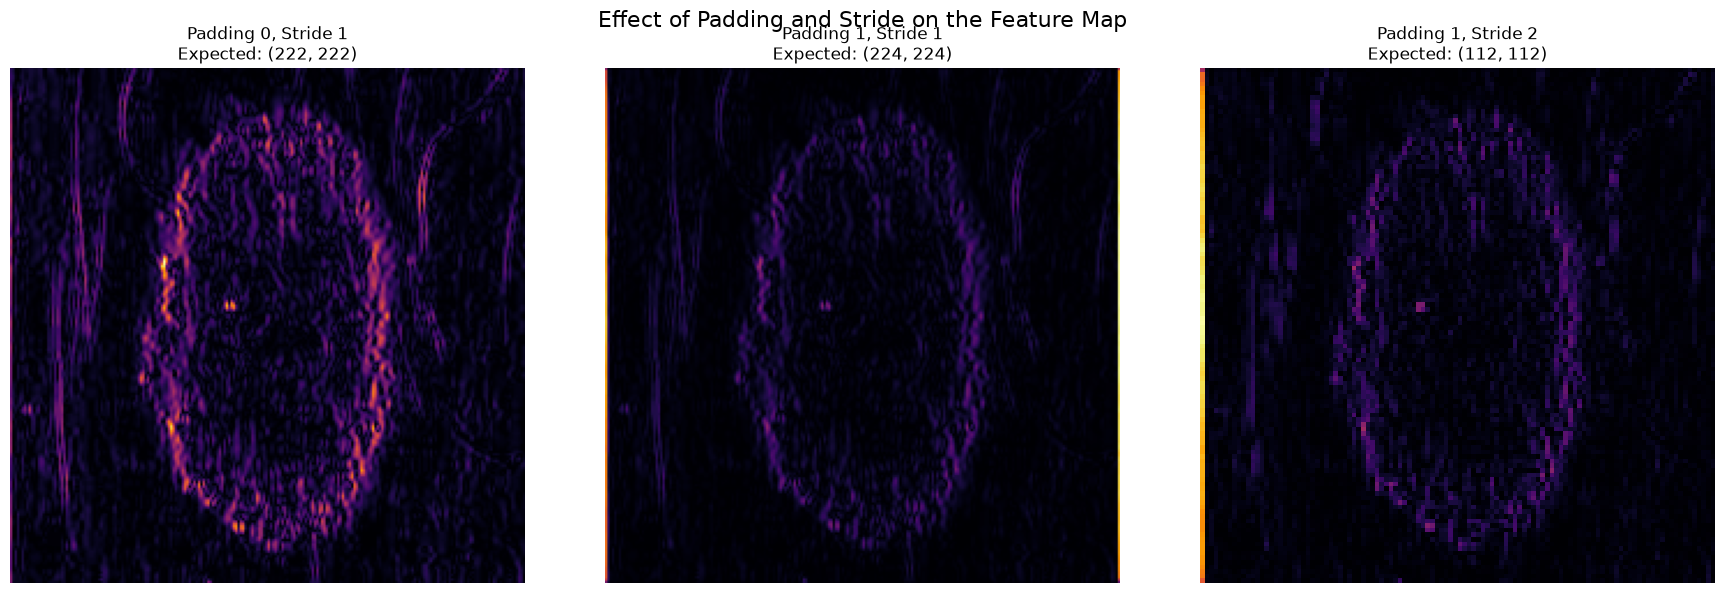

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

feature_maps = [
    valid_stride_1,
    same_stride_1,
    same_stride_2
]

titles = [
    "Padding 0, Stride 1\nExpected: (222, 222)",
    "Padding 1, Stride 1\nExpected: (224, 224)",
    "Padding 1, Stride 2\nExpected: (112, 112)"
]

for axis, feature_map, title in zip(
    axes,
    feature_maps,
    titles
):
    axis.imshow(
        np.abs(feature_map),
        cmap="inferno"
    )
    axis.set_title(title)
    axis.axis("off")

plt.suptitle(
    "Effect of Padding and Stride on the Feature Map",
    fontsize=16
)
plt.tight_layout()
plt.show()

<h3 style="color:#009E73;">Stride and Padding Interpretation</h3>

Without padding, the \(3\times3\) filter could not be centered on the border pixels, so each spatial dimension decreased from `224` to `222`.

Adding one pixel of padding preserved the original spatial dimensions when the stride was one.

Increasing the stride to two reduced each spatial dimension to `112`. The resulting feature map contained approximately one quarter as many positions as the `224 × 224` map:

$$
112\times112
=
\frac{224\times224}{4}
$$

A larger stride reduces memory use and computation, but it also samples fewer image positions and may discard small lesion details.

For the early layers of a medical-image classifier, a stride of one is a safer initial choice because small boundaries and texture changes may be diagnostically useful.

In [15]:
image_height = 224
image_width = 224
image_channels = 3
number_of_filters = 32
kernel_size = 3

flattened_inputs = (
    image_height
    * image_width
    * image_channels
)

dense_parameters = (
    flattened_inputs
    * number_of_filters
    + number_of_filters
)

convolution_parameters = (
    kernel_size
    * kernel_size
    * image_channels
    * number_of_filters
    + number_of_filters
)

parameter_reduction = (
    dense_parameters / convolution_parameters
)

parameter_comparison = pd.DataFrame([
    {
        "Layer": "Dense layer with 32 neurons",
        "Trainable Parameters": dense_parameters
    },
    {
        "Layer": "Conv2D with 32 filters",
        "Trainable Parameters": convolution_parameters
    }
])

display(parameter_comparison)

print(
    "The dense layer uses approximately",
    round(parameter_reduction, 1),
    "times more parameters."
)

,Layer,Trainable Parameters
0,Dense layer with 32 neurons,4816928
1,Conv2D with 32 filters,896


The dense layer uses approximately 5376.0 times more parameters.


<h3 style="color:#009E73;">Parameter-Sharing Results</h3>

Flattening an RGB image of shape:

$$
(224,224,3)
$$

produces:

$$
224\times224\times3=150,528
$$

input values.

Connecting these values to only 32 dense neurons requires:

$$
(150,528\times32)+32
=
4,816,928
$$

trainable parameters.

A convolutional layer with 32 RGB filters of size \(3\times3\) requires:

$$
(3\times3\times3\times32)+32
=
896
$$

trainable parameters.

Therefore, the dense layer uses approximately:

$$
\frac{4,816,928}{896}
\approx5,376
$$

times more parameters.

<span style="color:#009E73;"><b>Main Reason:</b></span>  
A dense layer assigns independent weights to every pixel-neuron connection. A convolutional layer learns a small filter and reuses its weights at every spatial location. This is called parameter sharing.

Reusing the filter also allows the same visual pattern to produce a response wherever it appears in the image. More precisely, convolution is translation-equivariant: moving a pattern moves its response in the feature map. Pooling and deeper aggregation can then make the final classification more robust to small changes in lesion position.

<h2 style="color:#0072B2;">Core-Architecture Decision</h2>

The melanoma dataset contains two-dimensional RGB images with important local and spatial relationships.

The selected core architecture is therefore:

$$
\boxed{\text{Two-Dimensional Convolutional Neural Network}}
$$

A dense-only network was rejected as the primary image model because it would:

- Require millions of parameters in its first layer.
- Ignore the explicit two-dimensional arrangement of pixels after flattening.
- Learn separate weights for the same pattern at different image locations.
- Be more vulnerable to overfitting and computational inefficiency.

A CNN is more appropriate because it:

- Processes small local image regions.
- Shares filters across the complete image.
- Preserves spatial structure.
- Learns visual features directly from the training images.
- Builds a hierarchy from simple patterns to more complex lesion representations.

The planned binary output layer is:

```python
Dense(1, activation="sigmoid")
```

with:

```python
loss="binary_crossentropy"
```

The output will represent the predicted probability of the malignant class.

<h2 style="color:#0072B2;">Improvement Carried from Sprint 1</h2>

Sprint 1 showed that model decisions should be supported by validation evidence rather than by training loss alone.

The improvement carried into Sprint 2 is:

> Change one major experimental factor at a time, record its configuration and validation metrics, and preserve the test set for one final evaluation.

This principle will be applied when comparing:

1. A CNN trained from scratch.
2. The same CNN with data augmentation.
3. A pre-trained transfer-learning model.
4. A carefully fine-tuned version of the selected model.

This makes it possible to determine which change caused an improvement instead of combining several changes and guessing which one helped.

<h2 style="color:#0072B2;">Day 1 Conclusion</h2>

Day 1 completed the Sprint 2 planning stage and established the architectural foundation for the melanoma image-classification project.

A total of `13,879` dermoscopic images were detected. The training set was reasonably balanced, the test set was perfectly balanced, and no missing or duplicate paths were found.

Two manually defined \(3\times3\) filters were applied to a malignant lesion. The resulting feature maps demonstrated how convolution extracts local intensity transitions such as boundaries and texture changes.

The stride and padding experiments confirmed that:

- No padding reduced the spatial shape from `(224, 224)` to `(222, 222)`.
- Padding of one preserved the `(224, 224)` shape.
- A stride of two reduced the output to `(112, 112)`.

Parameter sharing reduced the first-stage parameter count from `4,816,928` for a comparable dense layer to only `896` for a 32-filter convolutional layer.

<span style="color:#009E73;"><b>Final Day 1 Decision:</b></span>  
A two-dimensional CNN is the appropriate core architecture because it preserves spatial structure, learns local image patterns, and uses dramatically fewer parameters than a dense-only image model.

<span style="color:#D55E00;"><b>Next Step:</b></span>  
Day 2 will create a stratified validation split, build a complete CNN with convolution and pooling, add data augmentation, and compare the model against transfer learning.